In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, LeaveOneGroupOut, RandomizedSearchCV
from sklearn.linear_model import Ridge
from sklearn.multioutput import RegressorChain
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
from matplotlib.font_manager import FontProperties
from matplotlib.font_manager import findfont

#sns.set_palette([  "#89A8F6","#0F42C6",'#C9CED5',  "#1C2029"])

sns.set_style('darkgrid',{
    "axes.facecolor": "#f0f0f0",
    "axes.linewidth": 1.5,
    'axes.grid': True,
    'axes.labelcolor': '#000',
    "font.size": 18,
    'axes.edgecolor': '#fff',
    'grid.color': '#9d9d9d',
    'text.color': '#000',
    'xtick.color': '#000'
})

In [ ]:
df_a = pd.read_csv("bench_results/results_A.csv")
df_b = pd.read_csv("bench_results/results_B.csv")
df_c = pd.read_csv("bench_results/results_C.csv")

df = pd.concat([df_a, df_b, df_c], ignore_index=True)

In [29]:
df['estimated_nodes'] = df['F'] * (df['W']**(df['D'] + 1) - 1) / (df['W'] - 1)

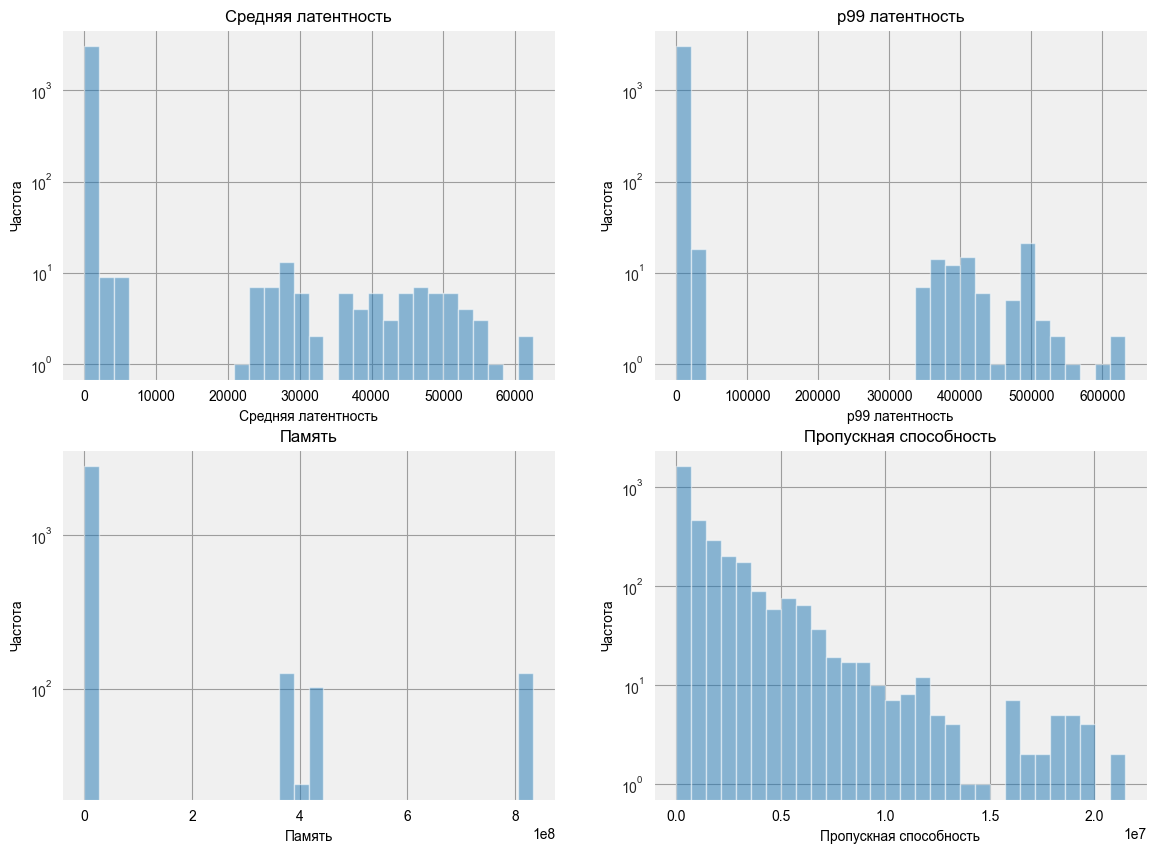

In [30]:
metrics = ['avg_latency_us', 'p99_latency_us', 'memory_usage_bytes', 'throughput_ops_sec']
titles = ['Средняя латентность', 'p99 латентность', 'Память', 'Пропускная способность']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, metric, title in zip(axes.flat, metrics, titles):
    ax.hist(df[metric], bins=30, alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel(title)
    ax.set_ylabel('Частота')
    ax.set_yscale('log')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


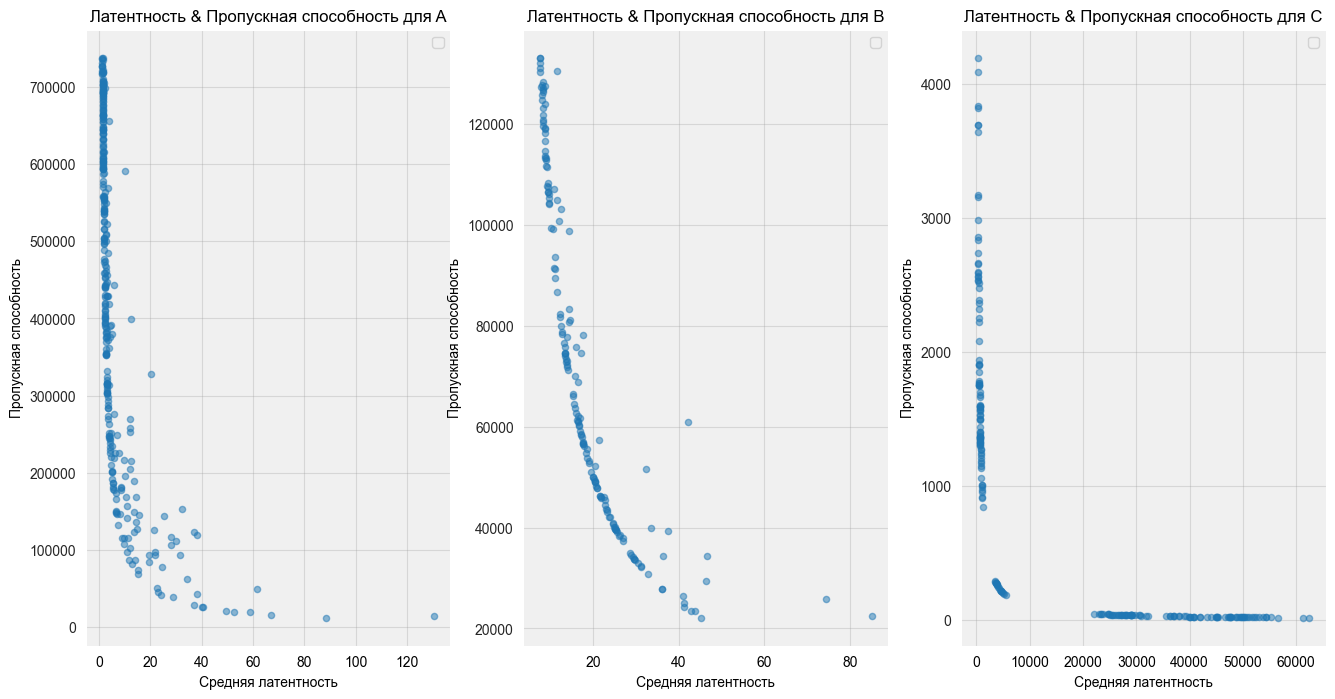

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 8))

approaches = ['A','B','C']

for i in [0, 1, 2]:
    sub = df[df['fs_type']==approaches[i]]
    if (sub["throughput_ops_sec"].max() > 1.5*1e7) :
        sub = sub[sub["throughput_ops_sec"] < sub["throughput_ops_sec"].max()/5000]
    elif(sub["throughput_ops_sec"].max() > 1e7):
        sub = sub[sub["throughput_ops_sec"] < sub["throughput_ops_sec"].max()/100]
    else :
        sub = sub[sub["throughput_ops_sec"] < sub["throughput_ops_sec"].max()/10]
        
    axes[i].scatter(sub['avg_latency_us'], sub['throughput_ops_sec'], alpha=0.5, s=20)
    axes[i].set_xlabel('Средняя латентность')
    axes[i].set_ylabel('Пропускная способность')
    axes[i].set_title(f'Латентность & Пропускная способность для {approaches[i]}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

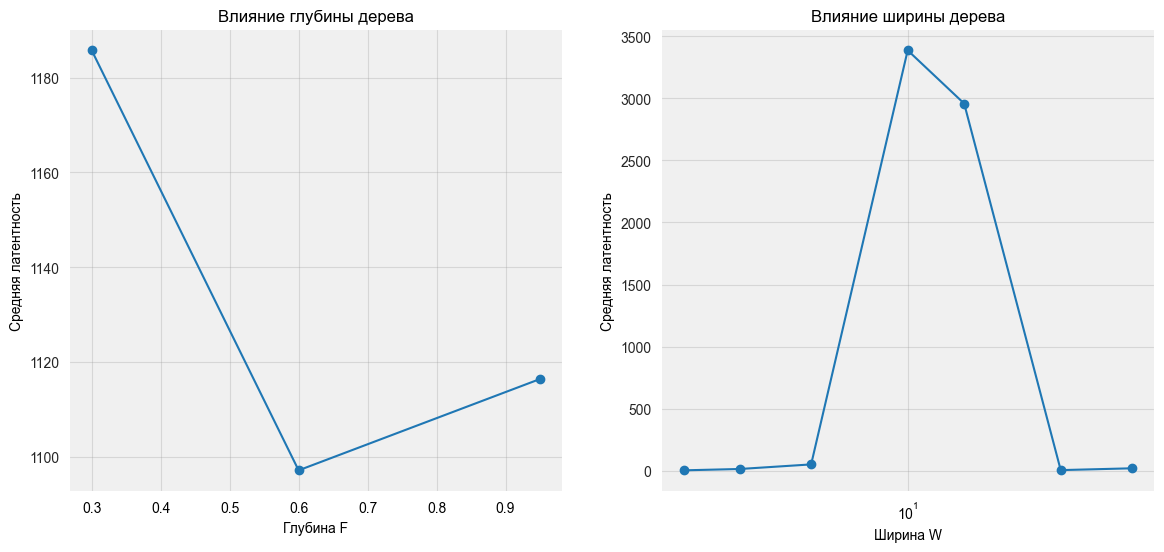

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

grouped = df.groupby('F')['avg_latency_us'].mean()
axes[0].plot(grouped.index, grouped.values, marker='o')
axes[0].set_xlabel('Глубина F')
axes[0].set_ylabel('Средняя латентность')
axes[0].set_title('Влияние глубины дерева')
axes[0].grid(True, alpha=0.3)

grouped = df.groupby('W')['avg_latency_us'].mean()
axes[1].plot(grouped.index, grouped.values, marker='o')
axes[1].set_xlabel('Ширина W')
axes[1].set_ylabel('Средняя латентность')
axes[1].set_title('Влияние ширины дерева')
axes[1].grid(True, alpha=0.3)
axes[1].set_xscale('log')

In [33]:
df

,fs_type,D,W,F,profile_name,p_read,p_write,p_mkdir,p_ls,p_mv,...,distribution,locality,zipf_s,operations,repeats,avg_latency_us,p99_latency_us,throughput_ops_sec,memory_usage_bytes,estimated_nodes
0,A,2,5,0.30,backup,0.1,0.7,0.0,0.0,0.2,...,uniform,0.0,0.0,2000,2,0.148005,0.4165,6757100.00,1582,9.30
1,A,2,5,0.30,backup,0.1,0.7,0.0,0.0,0.2,...,zipf,0.3,1.5,2000,2,0.135375,0.3545,7387580.00,1558,9.30
2,A,2,5,0.30,backup,0.1,0.7,0.0,0.0,0.2,...,zipf,0.8,2.0,2000,2,0.251316,0.6875,4017840.00,1542,9.30
3,A,2,5,0.60,backup,0.1,0.7,0.0,0.0,0.2,...,uniform,0.0,0.0,2000,2,0.146770,0.3955,6813810.00,3196,18.60
4,A,2,5,0.60,backup,0.1,0.7,0.0,0.0,0.2,...,zipf,0.3,1.5,2000,2,0.162033,0.3960,6171840.00,3172,18.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3208,C,3,50,0.60,web_server,0.8,0.1,0.0,0.1,0.0,...,zipf,0.3,1.5,2000,2,136.093000,1382.2300,7347.95,3035367,76530.60
3209,C,3,50,0.60,web_server,0.8,0.1,0.0,0.1,0.0,...,zipf,0.8,2.0,2000,2,121.639000,1358.4200,8221.07,3033042,76530.60
3210,C,3,50,0.95,web_server,0.8,0.1,0.0,0.1,0.0,...,uniform,0.0,0.0,2000,2,136.420000,1264.7500,7330.41,2703249,121173.45
3211,C,3,50,0.95,web_server,0.8,0.1,0.0,0.1,0.0,...,zipf,0.3,1.5,2000,2,117.978000,1239.4800,8476.20,2693391,121173.45


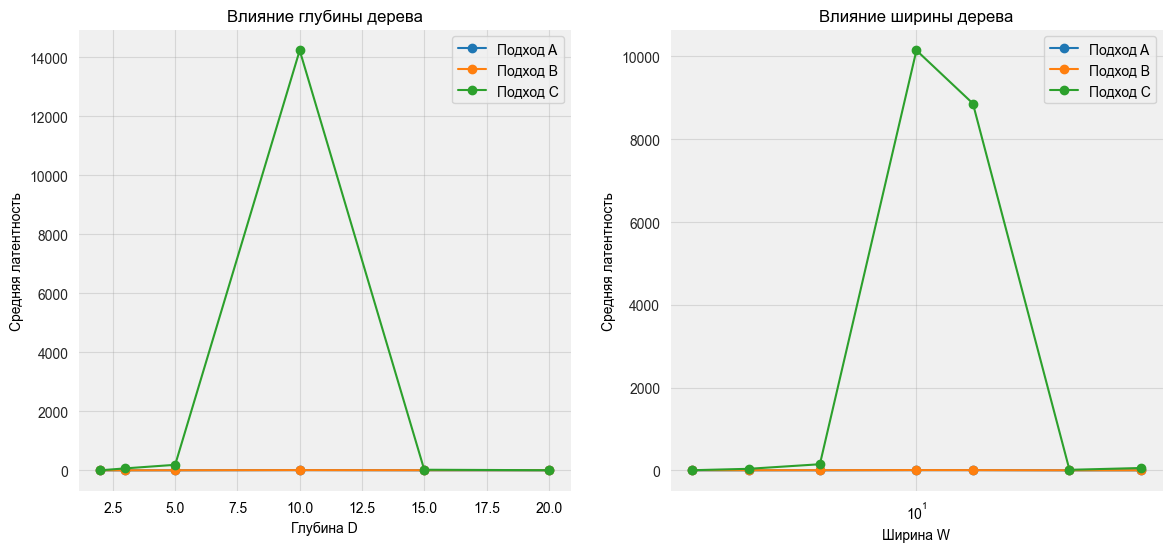

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for approach in ['A','B','C']:
    grouped = df[df['fs_type']==approach].groupby('D')['avg_latency_us'].mean()
    axes[0].plot(grouped.index, grouped.values, marker='o', label=f'Подход {approach}')
axes[0].set_xlabel('Глубина D')
axes[0].set_ylabel('Средняя латентность')
axes[0].set_title('Влияние глубины дерева')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for approach in ['A','B','C']:
    grouped = df[df['fs_type']==approach].groupby('W')['avg_latency_us'].mean()
    axes[1].plot(grouped.index, grouped.values, marker='o', label=f'Подход {approach}')
axes[1].set_xlabel('Ширина W')
axes[1].set_ylabel('Средняя латентность')
axes[1].set_title('Влияние ширины дерева')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xscale('log')

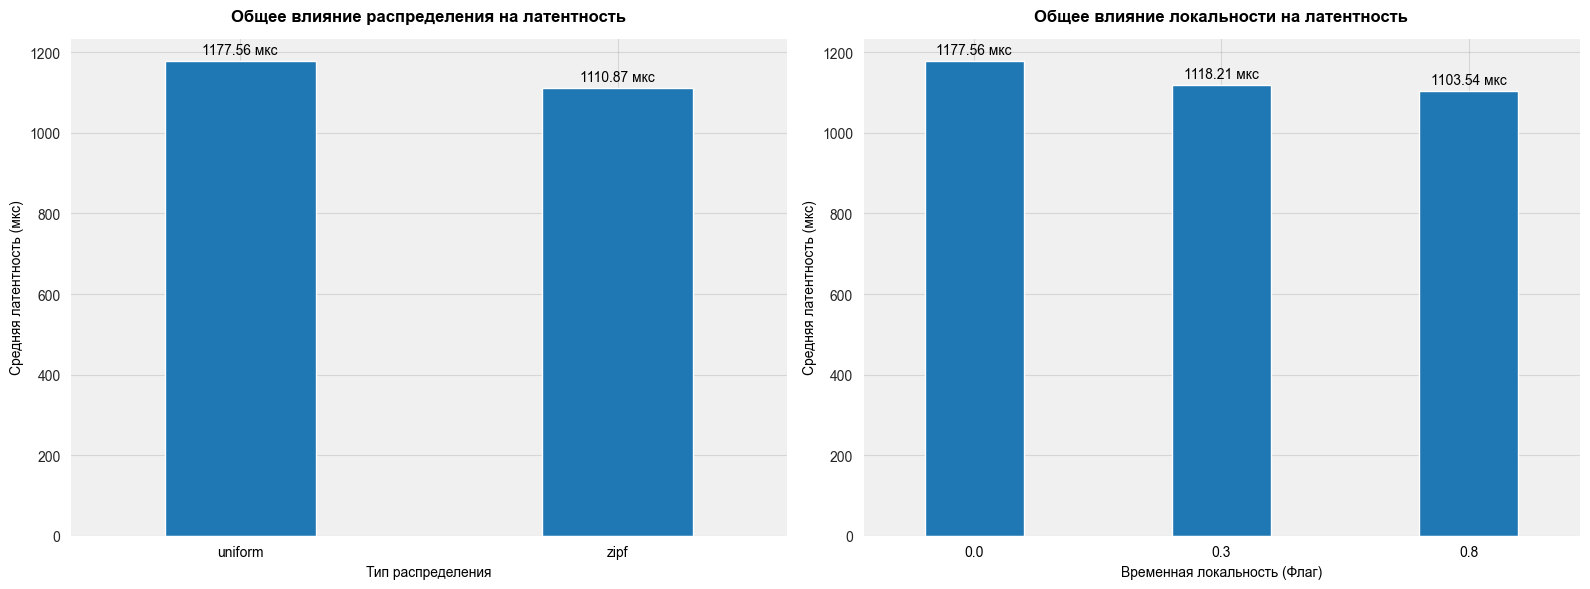

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

zipf_effect = df.groupby('distribution')['avg_latency_us'].mean()

zipf_effect.plot(kind='bar', ax=axes[0], width=0.4)
axes[0].set_title('Общее влияние распределения на латентность', fontweight='bold', pad=12)
axes[0].set_xlabel('Тип распределения')
axes[0].set_ylabel('Средняя латентность (мкс)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].grid(True, alpha=0.3)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.2f мкс', padding=3)

loc_effect = df.groupby('locality')['avg_latency_us'].mean()

loc_effect.plot(kind='bar', ax=axes[1], width=0.4)
axes[1].set_title('Общее влияние локальности на латентность', fontweight='bold', pad=12)
axes[1].set_xlabel('Временная локальность (Флаг)')
axes[1].set_ylabel('Средняя латентность (мкс)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].grid(True, alpha=0.3)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f мкс', padding=3)

plt.tight_layout()

Text(0.5, 1.0, 'Корреляционная матрица')

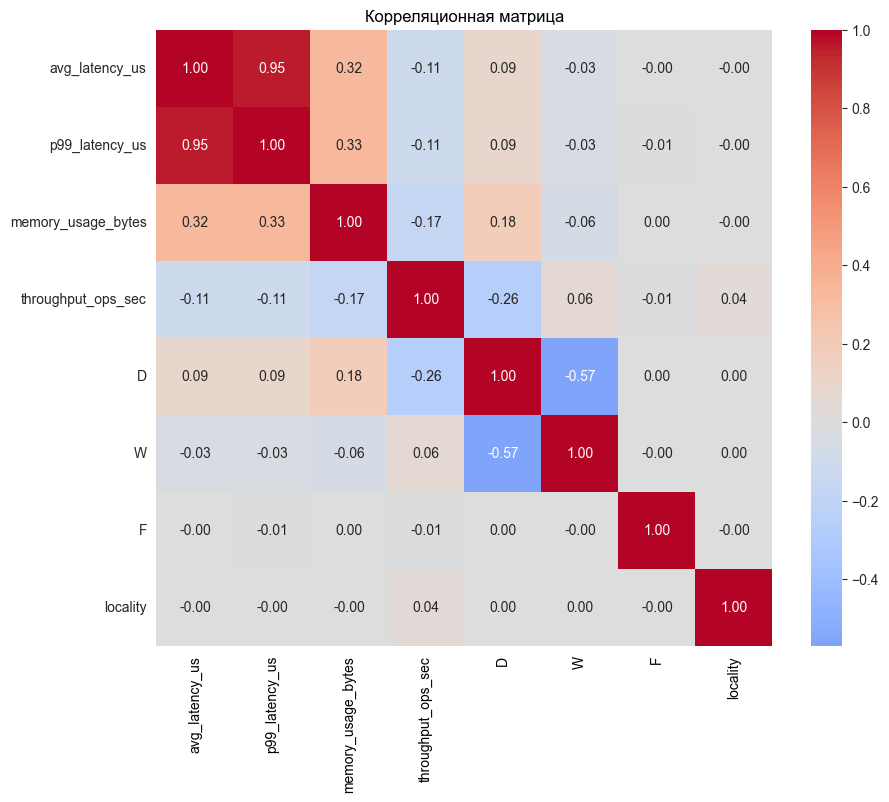

In [36]:
metric_cols = ['avg_latency_us','p99_latency_us','memory_usage_bytes','throughput_ops_sec','D','W','F','locality']
corr = df[metric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Корреляционная матрица')

Коэффициент корреляции Пирсона между avg_latency_us и p99_latency_us: 0.953


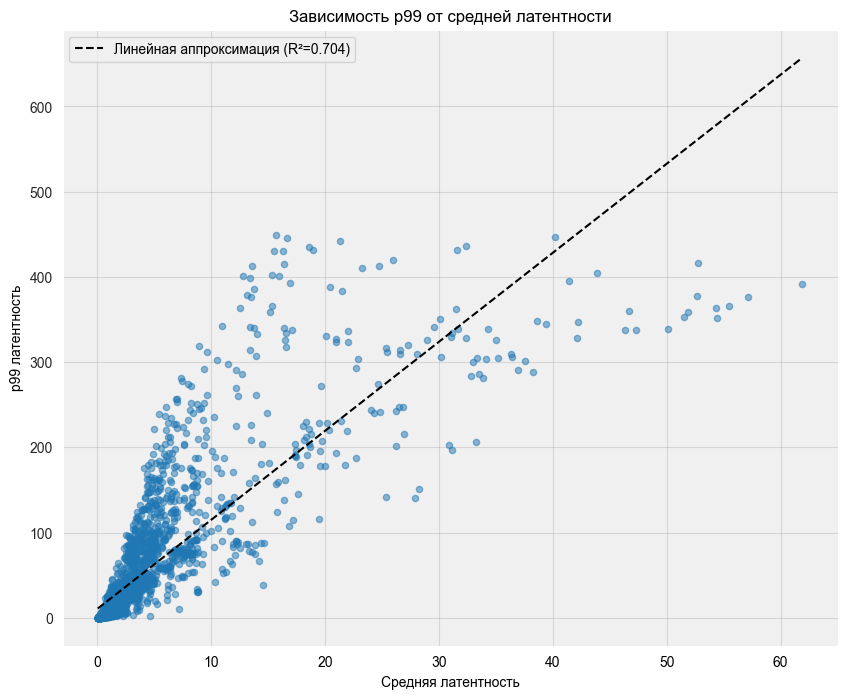

In [37]:
plt.figure(figsize=(10, 8))
sub = df[df['p99_latency_us']<450]
plt.scatter(sub['avg_latency_us'], sub['p99_latency_us'], alpha=0.5, s=20)

coef = np.polyfit(sub['avg_latency_us'], sub['p99_latency_us'], 1)
p = np.poly1d(coef)
x_line = np.linspace(sub['avg_latency_us'].min(), sub['avg_latency_us'].max(), 100)
r2_lin = np.corrcoef(sub['avg_latency_us'], sub['p99_latency_us'])[0,1]**2
plt.plot(x_line, p(x_line), 'k--', label=f'Линейная аппроксимация (R²={r2_lin:.3f})')

plt.xlabel('Средняя латентность')
plt.ylabel('p99 латентность')
plt.title('Зависимость p99 от средней латентности')
plt.legend()
plt.grid(True, alpha=0.3)

print(f"Коэффициент корреляции Пирсона между avg_latency_us и p99_latency_us: {pearsonr(df['avg_latency_us'], df['p99_latency_us'])[0]:.3f}")

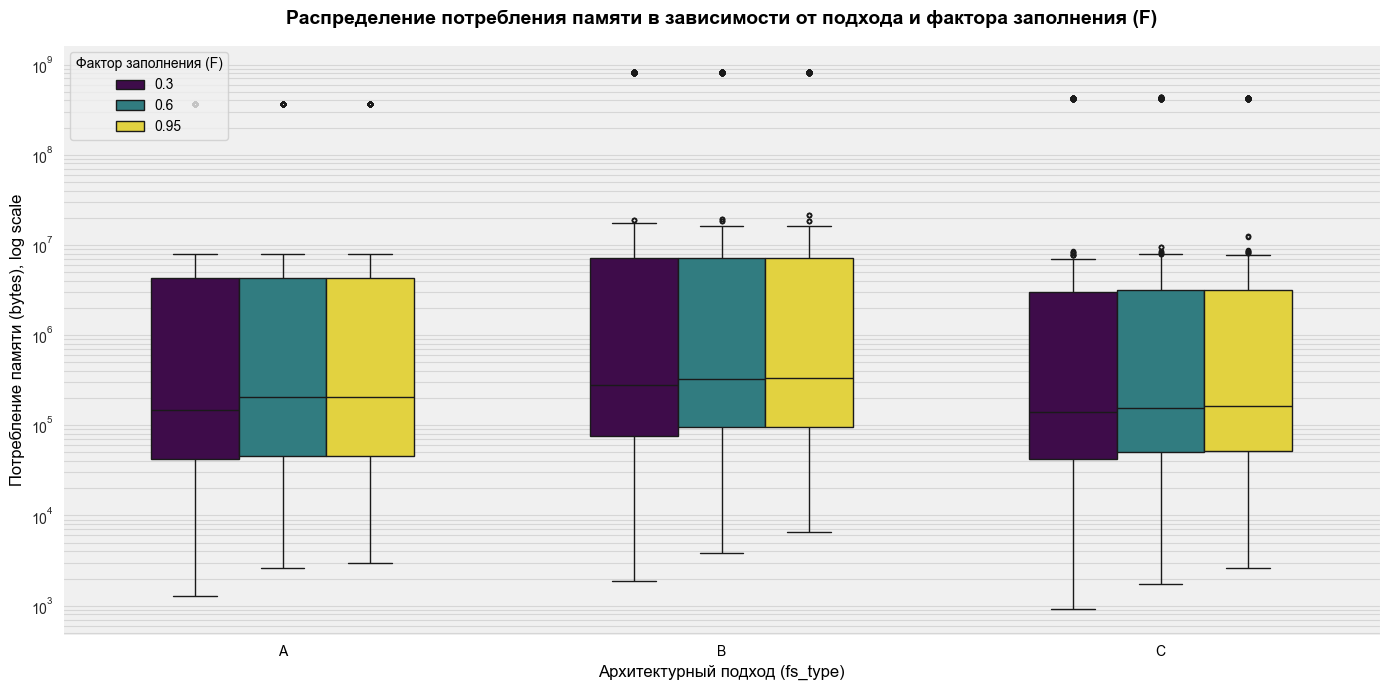

In [46]:

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df, 
    x='fs_type', 
    y='memory_usage_bytes', 
    hue='F', 
    palette='viridis', 
    width=0.6,
    fliersize=3
)

plt.yscale('log')

plt.title('Распределение потребления памяти в зависимости от подхода и фактора заполнения (F)', fontweight='bold', fontsize=14, pad=15)
plt.xlabel('Архитектурный подход (fs_type)', fontsize=12)
plt.ylabel('Потребление памяти (bytes), log scale', fontsize=12)
plt.legend(title='Фактор заполнения (F)', frameon=True, loc='upper left')
plt.grid(True, which="both", alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Коэффициент корреляции Пирсона между avg_latency_us и p99_latency_us: 0.844


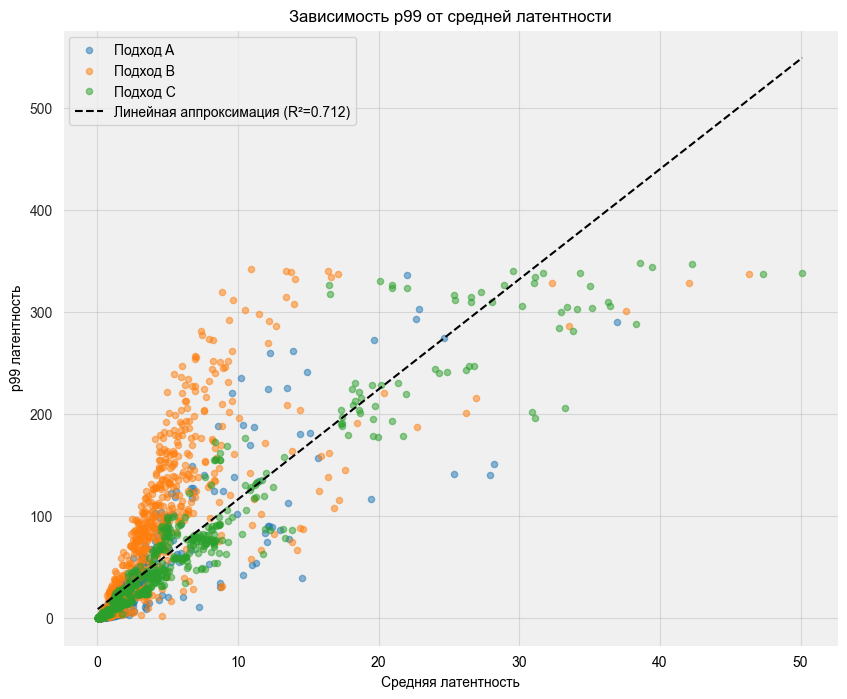

In [39]:
df_s = df[df['p99_latency_us']<350]

plt.figure(figsize=(10, 8))
for approach in ['A','B','C']:
    sub = df_s[df_s['fs_type']==approach]
    plt.scatter(sub['avg_latency_us'], sub['p99_latency_us'], alpha=0.5, s=20, label=f'Подход {approach}')

coef = np.polyfit(df_s['avg_latency_us'], df_s['p99_latency_us'], 1)
p = np.poly1d(coef)
x_line = np.linspace(df_s['avg_latency_us'].min(), df_s['avg_latency_us'].max(), 100)
r2_lin = np.corrcoef(df_s['avg_latency_us'], df_s['p99_latency_us'])[0,1]**2
plt.plot(x_line, p(x_line), 'k--', label=f'Линейная аппроксимация (R²={r2_lin:.3f})')

plt.xlabel('Средняя латентность')
plt.ylabel('p99 латентность')
plt.title('Зависимость p99 от средней латентности')
plt.legend()
plt.grid(True, alpha=0.3)

print(f"Коэффициент корреляции Пирсона между avg_latency_us и p99_latency_us: {pearsonr(df_s['avg_latency_us'], df_s['p99_latency_us'])[0]:.3f}")